In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
#from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
#from sklearn.metrics import accuracy_score, classification_report
"""
# Example data (replace with your actual data)
data = {
    'Freq [THz]': [1, 1.02, 1.04, 1.06, 1.08, 1.1, 1.12, 1.14, 1.16, 1.18, 1.2, 1.22],
    'S11-db': [-1.094, -1.143, -1.198, -1.259, -1.329, -1.407, -1.498, -1.606, -1.741, -1.927, -2.253, -2.675],
    'VSWR': [15.899, 15.217, 14.523, 13.818, 13.101, 12.370, 11.622, 10.845, 10.013, 9.050, 7.753, 6.545],
    'W1': [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]  # Target (constant in this case)
}
"""

# Convert to DataFrame
df = pd.read_csv("s11_vswr.csv")



C:\Users\91954\anaconda3\jupyter\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df.head(5)

,Freq_Thz,S11-db,VSWR,W1
0,1.00,-1.094076,15.899031,4
1,1.02,-1.143258,15.216907,4
2,1.04,-1.198070,14.522788,4
3,1.06,-1.259428,13.817549,4
4,1.08,-1.328606,13.100677,4


In [3]:
df.columns

Index(['Freq_Thz', 'S11-db', 'VSWR', 'W1'], dtype='object')

In [4]:
# Features (X) and Target (y)
#X = df[['Freq_THz', 'S11-db', 'VSWR']]  # Input features
X=df.drop(['W1','VSWR'],axis=1)
y = df['W1']  # Target output

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an SVM classifier
#svm_model = SVC(kernel='poly')  # You can change the kernel to 'rbf', 'poly', etc.

# Train the model
#svm_model.fit(X_train, y_train)

# Make predictions
#y_pred = svm_model.predict(X_test)

# Evaluate the model
#accuracy = accuracy_score(y_test, y_pred)
#print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification report
#print("\nClassification Report:")
#print(classification_report(y_test, y_pred))

# Create an SVR model
svr_model = SVR(kernel='linear')  # You can change the kernel to 'rbf', 'poly', etc.

# Train the model
svr_model.fit(X_train, y_train)

# Make predictions
y_pred = svr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)


Mean Squared Error (MSE): 361.5354
R-squared (R2): -0.0620

Predictions vs Actual:
      Actual  Predicted
1368      50  30.100077
65         4  30.099982
700       30  30.100073
938       40  30.100003
1621      60  30.100096
...      ...        ...
1308      50  30.100099
810       30  30.100078
1124      40  30.099996
118        4  30.100087
1486      50  30.100217

[542 rows x 2 columns]


In [43]:
svr_model = SVR(kernel='poly')  # You can change the kernel to 'rbf', 'poly', etc.

# Train the model
svr_model.fit(X_train, y_train)

# Make predictions
y_pred = svr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)


Mean Squared Error (MSE): 359.6508
R-squared (R2): -0.0564

Predictions vs Actual:
      Actual  Predicted
1368      50  30.588780
65         4  30.230044
700       30  30.343749
938       40  30.210153
1621      60  30.342820
...      ...        ...
1308      50  30.305609
810       30  30.869239
1124      40  31.333717
118        4  30.370002
1486      50  30.307129

[542 rows x 2 columns]


In [5]:
svr_model = SVR(kernel='rbf')  # You can change the kernel to 'rbf', 'poly', etc.

# Train the model
svr_model.fit(X_train, y_train)

# Make predictions
y_pred = svr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)


Mean Squared Error (MSE): 352.5845
R-squared (R2): -0.0357

Predictions vs Actual:
      Actual  Predicted
1368      50  31.499813
65         4  31.254295
700       30  31.476237
938       40  31.605002
1621      60  31.345553
...      ...        ...
1308      50  31.188399
810       30  31.168191
1124      40  30.145930
118        4  31.455276
1486      50  31.125079

[542 rows x 2 columns]


In [8]:
#import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV


# Define the SVR model
svr_model = SVR()

# Define the hyperparameter grid
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel types to try
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],  # Kernel coefficient
    'epsilon': [0.01, 0.1, 0.5, 1]  # Margin of tolerance
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=svr_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=2, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_svr_model = grid_search.best_estimator_

# Make predictions
y_pred = best_svr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

Fitting 2 folds for each of 240 candidates, totalling 480 fits
Best Hyperparameters: {'C': 10, 'epsilon': 1, 'gamma': 1, 'kernel': 'rbf'}
Mean Squared Error (MSE): 323.0107
R-squared (R2): 0.0512

Predictions vs Actual:
      Actual  Predicted
1368      50  42.707012
65         4  39.531750
700       30  38.754049
938       40  38.130087
1621      60  30.690198
...      ...        ...
1308      50  34.214885
810       30  40.482247
1124      40  44.637850
118        4  32.279732
1486      50  49.230172

[542 rows x 2 columns]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Define the SVR model
svr_model = SVR(C= 10, epsilon= 1, gamma= 1, kernel= 'rbf')

svr_model.fit(X_train, y_train)

# Make predictions
y_pred = svr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)


Mean Squared Error (MSE): 323.8380
R-squared (R2): 0.0723

Predictions vs Actual:
      Actual  Predicted
1368      50  42.026517
65         4  39.884154
700       30  40.653102
938       40  37.247951
1621      60  30.426801
...      ...        ...
1693      60  27.721058
416       20  32.040645
1036      40  40.577651
1317      50  30.768306
1740      60  49.073023

[362 rows x 2 columns]


In [7]:
from sklearn.linear_model import LinearRegression
#from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
#data = pd.read_csv('s11_vswr.csv')

# Features (X) and Target (y)
#X = data[['Freq_Thz', 'S11-db', 'VSWR']]  # Input features
#y = data['W1']  # Target output

# Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred = linear_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

# Print model coefficients
print("\nModel Coefficients:")
print(linear_model.coef_)
print("Intercept:", linear_model.intercept_)

Mean Squared Error (MSE): 348.6326
R-squared (R2): 0.0013

Predictions vs Actual:
      Actual  Predicted
1368      50  33.898929
65         4  33.734058
700       30  33.989983
938       40  33.855596
1621      60  34.040059
...      ...        ...
1693      60  33.523913
416       20  34.020565
1036      40  33.379829
1317      50  34.096353
1740      60  34.025525

[362 rows x 2 columns]

Model Coefficients:
[0.05548525 0.06419717]
Intercept: 34.254640151225644


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
#data = pd.read_csv('s11_vswr.csv')

# Features (X) and Target (y)
#X = data[['Freq_Thz', 'S11-db', 'VSWR']]  # Input features
#y = data['W1']  # Target output

# Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the ElasticNet model
elastic_net_model = ElasticNet()

# Define the hyperparameter grid for alpha and l1_ratio
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]  # Mix of L1 and L2 regularization
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=elastic_net_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_elastic_net_model = grid_search.best_estimator_

# Make predictions
y_pred = best_elastic_net_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

# Print model coefficients
print("\nModel Coefficients:")
print(best_elastic_net_model.coef_)
print("Intercept:", best_elastic_net_model.coef_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Hyperparameters: {'alpha': 10, 'l1_ratio': 0.3}
Mean Squared Error (MSE): 349.2685
R-squared (R2): -0.0005

Predictions vs Actual:
      Actual  Predicted
1368      50  33.915512
65         4  33.915512
700       30  33.915512
938       40  33.915512
1621      60  33.915512
...      ...        ...
1693      60  33.915512
416       20  33.915512
1036      40  33.915512
1317      50  33.915512
1740      60  33.915512

[362 rows x 2 columns]

Model Coefficients:
[0. 0. 0.]
Intercept: 33.91551246537396


In [8]:
import pandas as pd
import numpy as np
#from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
#data = pd.read_csv('s11_vswr.csv')

# Features (X) and Target (y)
#X = data[['Freq_Thz', 'S11-db', 'VSWR']]  # Input features
#y = data['W1']  # Target output

# Split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the degree of the polynomial
degree = 2  # You can change this to 3, 4, etc.

# Transform features to polynomial features
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Initialize the Linear Regression model
linear_model = LinearRegression()

# Train the model on polynomial features
linear_model.fit(X_train_poly, y_train)

# Make predictions
y_pred = linear_model.predict(X_test_poly)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

# Print model coefficients
print("\nModel Coefficients:")
print(linear_model.coef_)
print("Intercept:", linear_model.intercept_)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

Mean Squared Error (MSE): 349.1968
R-squared (R2): -0.0003

Predictions vs Actual:
      Actual  Predicted
1368      50  34.106459
65         4  34.050234
700       30  34.046603
938       40  34.194068
1621      60  33.976211
...      ...        ...
1693      60  33.877339
416       20  34.000004
1036      40  33.331256
1317      50  33.898519
1740      60  34.114509

[362 rows x 2 columns]

Model Coefficients:
[ 0.         -0.45499876 -0.12900579  0.01550413 -0.03856879 -0.01424609]
Intercept: 34.26883599944812

Predictions vs Actual:
      Actual  Predicted
1368      50  34.106459
65         4  34.050234
700       30  34.046603
938       40  34.194068
1621      60  33.976211
...      ...        ...
1693      60  33.877339
416       20  34.000004
1036      40  33.331256
1317      50  33.898519
1740      60  34.114509

[362 rows x 2 columns]


In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Create a pipeline with PolynomialFeatures and LinearRegression
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('linear', LinearRegression())
])

# Define the hyperparameter grid for the polynomial degree
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5]  # Try different degrees
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_poly_model = grid_search.best_estimator_

# Make predictions
y_pred = best_poly_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Hyperparameters: {'poly__degree': 1}
Mean Squared Error (MSE): 348.0659
R-squared (R2): 0.0029


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

Mean Squared Error (MSE): 291.1160
R-squared (R2): 0.1661

Predictions vs Actual:
      Actual  Predicted
1368      50      46.20
65         4      43.08
700       30      31.84
938       40      38.18
1621      60      22.66
...      ...        ...
1693      60      25.82
416       20      19.06
1036      40      36.88
1317      50      35.42
1740      60      44.42

[362 rows x 2 columns]


In [10]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the model
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred = gb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

Mean Squared Error (MSE): 298.5847
R-squared (R2): 0.1447

Predictions vs Actual:
      Actual  Predicted
1368      50  36.780228
65         4  34.676421
700       30  35.965054
938       40  37.605323
1621      60  34.252043
...      ...        ...
1693      60  30.186360
416       20  34.885483
1036      40  31.195880
1317      50  31.879213
1740      60  37.399020

[362 rows x 2 columns]


In [11]:
from xgboost import XGBRegressor

# Initialize the model
xgb_model = XGBRegressor(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

Mean Squared Error (MSE): 319.2454
R-squared (R2): 0.0855

Predictions vs Actual:
      Actual  Predicted
1368      50  53.047367
65         4  51.417786
700       30  25.776680
938       40  31.354280
1621      60  22.041843
...      ...        ...
1693      60  25.197071
416       20  21.229351
1036      40  37.265587
1317      50  42.145576
1740      60  45.839375

[362 rows x 2 columns]


In [13]:
!pip install lightgbm

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB 435.7 kB/s eta 0:00:04
   --- ------------------------------------ 0.1/1.5 MB 1.2 MB/s eta 0:00:02
   ---------------- ----------------------- 0.6/1.5 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.5 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 7.1 MB/s eta 0:00:00


In [14]:

from lightgbm import LGBMRegressor

# Initialize the model
lgbm_model = LGBMRegressor(random_state=42)

# Train the model
lgbm_model.fit(X_train, y_train)

# Make predictions
y_pred = lgbm_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 500
[LightGBM] [Info] Number of data points in the train set: 1444, number of used features: 2
[LightGBM] [Info] Start training from score 33.915512
Mean Squared Error (MSE): 271.5277
R-squared (R2): 0.2222

Predictions vs Actual:
      Actual  Predicted
1368      50  51.277037
65         4  39.508362
700       30  36.312168
938       40  38.806770
1621      60  20.270684
...      ...        ...
1693      60  23.711514
416       20  20.144167
1036      40  36.998516
1317      50  33.904368
1740      60  45.558742

[362 rows x 2 columns]


In [16]:
!pip install catboost

  Obtaining dependency information for catboost from https://files.pythonhosted.org/packages/1c/e1/78e635a1e5f0066bd02a1ecfd658ad09fe30d275c65c2d0dd76fe253e648/catboost-1.2.7-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for graphviz from https://files.pythonhosted.org/packages/00/be/d59db2d1d52697c6adc9eacaf50e8965b6345cc143f671e1ed068818d5cf/graphviz-0.20.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 653.6 kB/s eta 0:02:36
   ---------------------------------------- 0.2/101.7 MB 2.1 MB/s eta 0:00:50
   ---------------------------------------- 0.6/101.7 MB 4.0 MB/s eta 0:00:26
    --------------------------------------- 1.6/101.7 MB 8.3 MB/s eta 0:00:13
    --------------------------------------- 2.5/101.7 MB 10.6 MB/s eta 0:00:10
   - -------------------------------------- 3.7/101.7

In [17]:
from catboost import CatBoostRegressor

# Initialize the model
cat_model = CatBoostRegressor(random_state=42, verbose=0)

# Train the model
cat_model.fit(X_train, y_train)

# Make predictions
y_pred = cat_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)


Mean Squared Error (MSE): 248.8217
R-squared (R2): 0.2872

Predictions vs Actual:
      Actual  Predicted
1368      50  45.198389
65         4  38.339862
700       30  40.622310
938       40  36.207686
1621      60  30.350158
...      ...        ...
1693      60  28.143854
416       20  27.233068
1036      40  36.176152
1317      50  35.018353
1740      60  41.087720

[362 rows x 2 columns]


In [19]:
!pip install tensorflow

  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/3c/e3/e868f1d5951047f950d2ba1e04a765a3328a51f06996b67976d6102f8227/tensorflow-2.19.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/a2/ad/e0d3c824784ff121c03cc031f944bc7e139a8f1870ffd2845cc2dd76f6c4/absl_py-2.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=24.3.25 from https://files.pythonhosted.org/packages/b8/25/155f9f080d5e4bc0082edfda032ea2bc2b8fab3f4d25d46c1e9dd22a1a89/flatbuffers-25.2.10-py2.py3-none-any.whl.metadata
  Obtaining dependency information for gast!=0.5.0,!=0.5.1,!=0.5.2,>=0.2.1 from https://files.pythonhosted.org/packages/a3/61/8001b38461d751c

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Initialize the model
nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # Input layer
nn_model.add(Dense(32, activation='relu'))  # Hidden layer
nn_model.add(Dense(1))  # Output layer

# Compile the model
nn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
nn_model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

# Make predictions
y_pred = nn_model.predict(X_test).flatten()

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

ImportError: Traceback (most recent call last):
  File "C:\Users\91954\anaconda3\jupyter\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [21]:
from sklearn.neighbors import KNeighborsRegressor

# Initialize the model
knn_model = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred = knn_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

Mean Squared Error (MSE): 338.9308
R-squared (R2): 0.0291

Predictions vs Actual:
      Actual  Predicted
1368      50       40.0
65         4       30.8
700       30       44.0
938       40       38.0
1621      60       26.8
...      ...        ...
1693      60       24.8
416       20       25.6
1036      40       44.0
1317      50       28.8
1740      60       42.0

[362 rows x 2 columns]


C:\Users\91954\anaconda3\jupyter\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


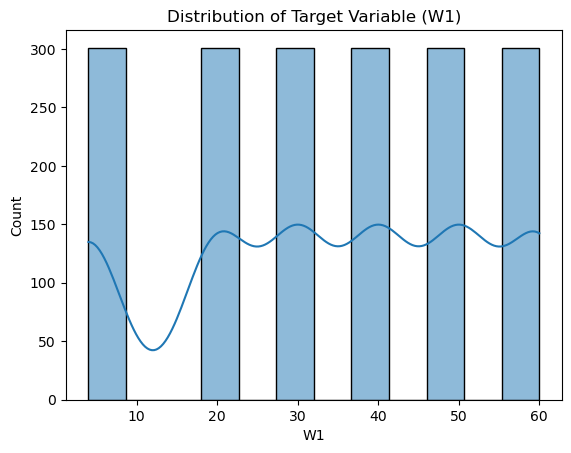

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distribution of the target variable
sns.histplot(df['W1'], kde=True)
plt.title("Distribution of Target Variable (W1)")
plt.show()

In [ ]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)

In [ ]:
# Print predictions vs actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPredictions vs Actual:")
print(results)
